In [1]:
#Import Dataset

import pandas as pd

data = pd.read_csv("wine.csv")

print(data.head())

   Wine  Alcohol  Malic.acid   Ash   Acl   Mg  Phenols  Flavanoids  \
0     1    14.23        1.71  2.43  15.6  127     2.80        3.06   
1     1    13.20        1.78  2.14  11.2  100     2.65        2.76   
2     1    13.16        2.36  2.67  18.6  101     2.80        3.24   
3     1    14.37        1.95  2.50  16.8  113     3.85        3.49   
4     1    13.24        2.59  2.87  21.0  118     2.80        2.69   

   Nonflavanoid.phenols  Proanth  Color.int   Hue    OD  Proline  
0                  0.28     2.29       5.64  1.04  3.92     1065  
1                  0.26     1.28       4.38  1.05  3.40     1050  
2                  0.30     2.81       5.68  1.03  3.17     1185  
3                  0.24     2.18       7.80  0.86  3.45     1480  
4                  0.39     1.82       4.32  1.04  2.93      735  


In [2]:
data.shape

(178, 14)

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [4]:
data.isnull().sum()

Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64

In [5]:
x = data.drop("Wine", axis=1)
y = data["Wine"]

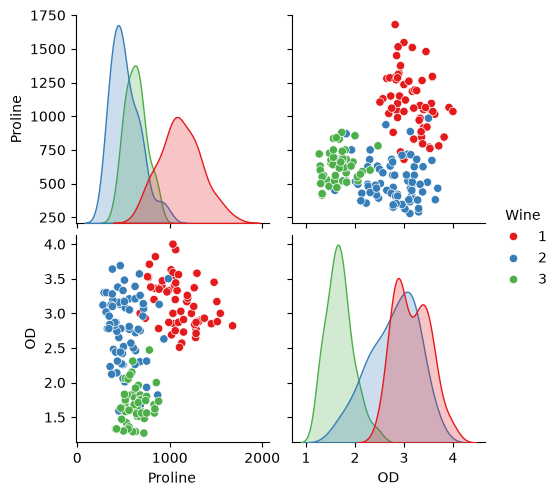

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt


p_data = data[['Wine', 'Proline', 'OD']]
sns.pairplot(p_data, hue='Wine', palette='Set1')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(124, 13) (54, 13) (124,) (54,)


In [8]:
y.value_counts()

Wine
2    71
1    59
3    48
Name: count, dtype: int64

## Random Forest Hyperparameter Tuning — `n_estimators`

/home/noob_coder/Desktop/ML_Lab/myenv/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/noob_coder/Desktop/ML_Lab/myenv/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/noob_coder/Desktop/ML_Lab/myenv/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/noob_coder/Desktop/ML_Lab/myenv/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/noob_coder/Desktop/ML_Lab/myenv/li

Number of Tree:  38
Best OOB_Score: 0.9838709677419355


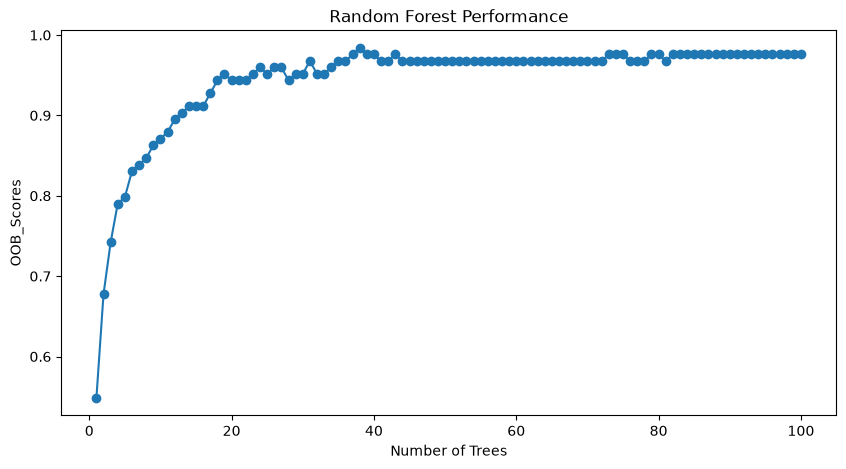


Final Random Forest
Best n_estimators: 38
Test Accuracy: 1.0
OOB Score: 0.9838709677419355
OOB Error: 0.016129032258064502

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        21
           3       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54

Confusion Matrix:
 [[18  0  0]
 [ 0 21  0]
 [ 0  0 15]]
Alcohol : 0.12382669328293278
Malic.acid : 0.04692106302771784
Ash : 0.018707834683283384
Acl : 0.0142838397455463
Mg : 0.054287052306838134
Phenols : 0.04063678875898203
Flavanoids : 0.18364594874387508
Nonflavanoid.phenols : 0.012009290100142535
Proanth : 0.01796829499924837
Color.int : 0.1502650357000058
Hue : 0.14185049800027777
OD : 0.09136868685520176
Proline : 0.10422897379594828


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix


# score = []
# best=0
# nt=0
# best_oob_score = 0
# for i in range(1,101):
#     rf = RandomForestClassifier(n_estimators = i, random_state=42, oob_score= True)
#     model = rf.fit(X_train, y_train)
#     r_prediction = model.predict(X_test)
#     acc = accuracy_score(y_test, r_prediction)
#     if acc > best:
#         nt=i
#         best=acc
#     score.append(acc)  

oob_scores = []
best_oob_score = 0
nt = 0

for i in range(1, 101):
    rf = RandomForestClassifier(n_estimators=i, random_state=42, oob_score=True)
    rf.fit(X_train, y_train)
    oob_score = rf.oob_score_
    oob_scores.append(oob_score)

    if oob_score > best_oob_score:
        best_oob_score = oob_score
        nt = i

print("Number of Tree: ",nt)
print("Best OOB_Score:", best_oob_score)

plt.figure(figsize=(10,5))
plt.plot(range(1,101), oob_scores, marker= 'o')
plt.xlabel("Number of Trees")
plt.ylabel("OOB_Scores")
plt.title("Random Forest Performance")
plt.show()

# Train the final Random Forest using the best n_estimators
best_rf = RandomForestClassifier(
    n_estimators=nt,
    random_state=42,
    oob_score=True
)
best_rf.fit(X_train, y_train)

best_rf_pred = best_rf.predict(X_test)

print("\nFinal Random Forest")
print("Best n_estimators:", nt)
print("Test Accuracy:", accuracy_score(y_test, best_rf_pred))
print("OOB Score:", best_rf.oob_score_)
print("OOB Error:", 1 - best_rf.oob_score_)

print("\nClassification Report:\n", classification_report(y_test, best_rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, best_rf_pred))
importance = best_rf.feature_importances_

for feature, value in zip(X_train.columns, importance):
    print(feature, ":", value)


In [10]:
from sklearn.preprocessing import StandardScaler
X_train_scaled = StandardScaler().fit_transform(X_train)
X_test_scaled = StandardScaler().fit_transform(X_test)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


SVM Classifier
Test Accuracy: 0.9814814814814815
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.95      1.00      0.98        21
           2       1.00      0.93      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54

Confusion Matrix:
 [[18  0  0]
 [ 0 21  0]
 [ 0  1 14]]


/tmp/ipykernel_15540/2682798463.py:31: UserWarning: You passed an edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test_encoded, cmap='viridis', edgecolors='k', s=40, marker='x', label='Test')


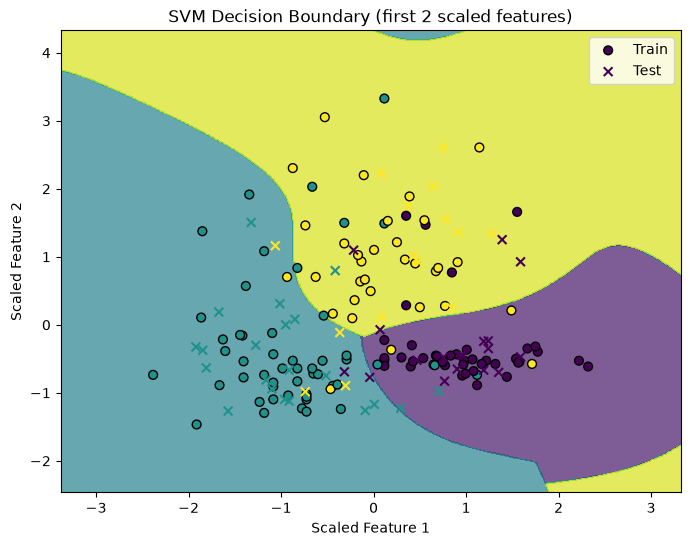

In [ ]:
from sklearn.svm import SVC
import numpy as np

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train_encoded)
y_pred_svm = svm_model.predict(X_test_scaled)

print("\nSVM Classifier")
print("Test Accuracy:", accuracy_score(y_test_encoded, y_pred_svm))
print("Classification Report:\n", classification_report(y_test_encoded, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred_svm))

# Use the first two scaled features to visualize the decision boundary
X_vis_train = X_train_scaled[:, :2]
y_vis_train = y_train_encoded

svc_vis = SVC(kernel='rbf', random_state=42)
svc_vis.fit(X_vis_train, y_vis_train)

x_min, x_max = X_vis_train[:, 0].min() - 1, X_vis_train[:, 0].max() + 1
y_min, y_max = X_vis_train[:, 1].min() - 1, X_vis_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)
Z = svc_vis.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.7, cmap='viridis')
plt.scatter(X_vis_train[:, 0], X_vis_train[:, 1], c=y_vis_train, cmap='viridis', edgecolors='k', s=40, label='Train')
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test_encoded, cmap='viridis', edgecolors='k', s=40, marker='x', label='Test')
plt.xlabel('Scaled Feature 1')
plt.ylabel('Scaled Feature 2')
plt.title('SVM Decision Boundary (first 2 scaled features)')
plt.legend()
plt.show()

## KNN Hyperparameter Tuning — `n_estimators`

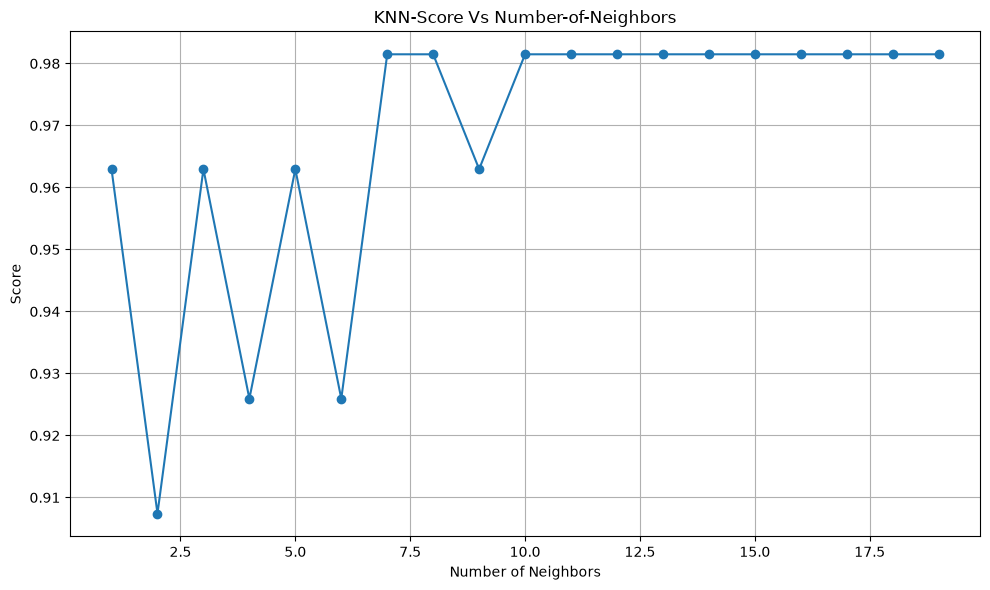

Best K:  7
Best KNN Accuracy:  0.9814814814814815
Best Model Accuracy Score:  0.9814814814814815
Classification Report : 
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        18
           2       1.00      0.95      0.98        21
           3       0.94      1.00      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54

Confusion Matrix: 
 [[18  0  0]
 [ 0 20  1]
 [ 0  0 15]]


In [12]:
from sklearn.neighbors import KNeighborsClassifier
knn_score = []
best_k = 0
knn_best_accuracy = 0

for i in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn_model = knn.fit(X_train_scaled, y_train)
    knn_predict = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, knn_predict)

    if acc > knn_best_accuracy:
        knn_best_accuracy = acc
        best_k = i
    knn_score.append(acc)

plt.figure(figsize=(10,6))
plt.title("KNN-Score Vs Number-of-Neighbors")
plt.plot(range(1, 20), knn_score, marker='o')
plt.xlabel("Number of Neighbors")
plt.ylabel("Score")
plt.tight_layout()
plt.grid(True)
plt.show()

print("Best K: ", best_k)
print("Best KNN Accuracy: ", knn_best_accuracy)

knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn_model = knn.fit(X_train_scaled, y_train)
knn_predict = best_knn_model.predict(X_test_scaled)

print("Best Model Accuracy Score: ", accuracy_score(y_test, knn_predict))
print("Classification Report : \n", classification_report(y_test, knn_predict))
print("Confusion Matrix: \n", confusion_matrix(y_test, knn_predict))


In [13]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
model = nb_model.fit(X_train_scaled,y_train)
nb_predict = model.predict(X_test_scaled)

print("Best Naive Bayes Accuracy Score: ", accuracy_score(y_test, nb_predict))
print("Naive Bayes Classification Report : \n", classification_report(y_test, nb_predict))
print("Naive Bayes Confusion Matrix: \n", confusion_matrix(y_test, nb_predict))


Best Naive Bayes Accuracy Score:  0.9814814814814815
Naive Bayes Classification Report : 
               precision    recall  f1-score   support

           1       1.00      0.94      0.97        18
           2       0.95      1.00      0.98        21
           3       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54

Naive Bayes Confusion Matrix: 
 [[17  1  0]
 [ 0 21  0]
 [ 0  0 15]]


In [14]:
from sklearn.linear_model import LogisticRegression

lg = LogisticRegression(max_iter = 2500, random_state=42)
lg_model = lg.fit(X_train_scaled, y_train)
lg_prediction = lg_model.predict(X_test_scaled)

print("Logistic Regression Accuracy Score: ", accuracy_score(y_test, lg_prediction))
print("Logistic Regression Classification Report : \n", classification_report(y_test, lg_prediction))
print("Logistic Regression Confusion Matrix: \n", confusion_matrix(y_test, lg_prediction))

Logistic Regression Accuracy Score:  0.9814814814814815
Logistic Regression Classification Report : 
               precision    recall  f1-score   support

           1       0.95      1.00      0.97        18
           2       1.00      0.95      0.98        21
           3       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54

Logistic Regression Confusion Matrix: 
 [[18  0  0]
 [ 1 20  0]
 [ 0  0 15]]


## PCA 

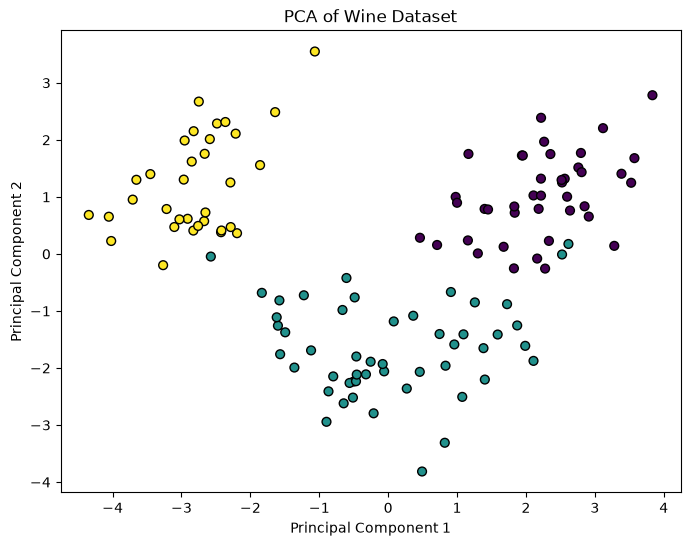

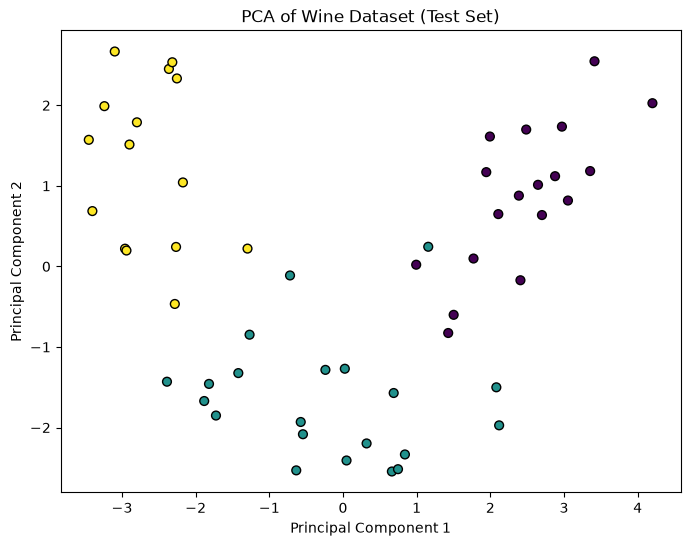

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', edgecolor='k', s=40)
plt.title('PCA of Wine Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2') 
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='viridis', edgecolor='k', s=40)
plt.title('PCA of Wine Dataset (Test Set)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()